# Publication-Ready Figures: AMR Prediction in *Burkholderia pseudomallei*

## Comprehensive Model Comparison and Data Exploration

This notebook generates publication-quality figures for:
- Data exploration (PCA, Correspondence Analysis)
- Model performance comparison (accuracy, AUC, ROC curves)
- Biomarker consensus analysis (Venn diagrams)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# For Venn diagrams
from matplotlib_venn import venn3

# ML imports
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, auc, roc_auc_score
import xgboost as xgb
import prince

# Set publication-quality style
sns.set_style('whitegrid')
sns.set_palette("pastel")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

## 1. Load Data and Results

In [37]:
# Load SNP features and labels
snp_data = pd.read_csv('snps_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = snp_data.values
y = profiles.values
snp_names = snp_data.columns.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

# Data split (matching other notebooks)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)
X_train_total = np.vstack([X_train, X_val])
y_train_total = np.concatenate([y_train, y_val])

print(f'Data loaded: {X.shape[0]} samples, {X.shape[1]} SNP features')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Resistance profiles: {np.unique(y)}')

Data shape: (227, 9754)
Label shape: (227, 1)
Categories: [0 1]
Data loaded: 227 samples, 9754 SNP features
Test set: 69 samples
Resistance profiles: [0 1]


In [5]:
# Load model results
results_df = pd.read_csv('model_results.csv')
print('\nModel Results:')
print(results_df)


Model Results:
                    model                                    hyperparameters  \
0     K-Nearest Neighbors                                               k=31   
1  Support Vector Machine                            kernel=linear, C=0.0100   
2           Decision Tree                  max_depth=10, min_samples_split=5   
3     Logistic Regression                                        C=1000.0000   
4                 XGBoost  max_depth=3, learning_rate=0.1, reg_alpha=0.1,...   

   test_accuracy  cv_score  
0       0.681159  0.716532  
1       0.710145  0.835887  
2       0.637681  0.754839  
3       0.782609  0.830040  
4       0.782609  0.817339  


## 2. Data Exploration

### 2.1 Data Summary

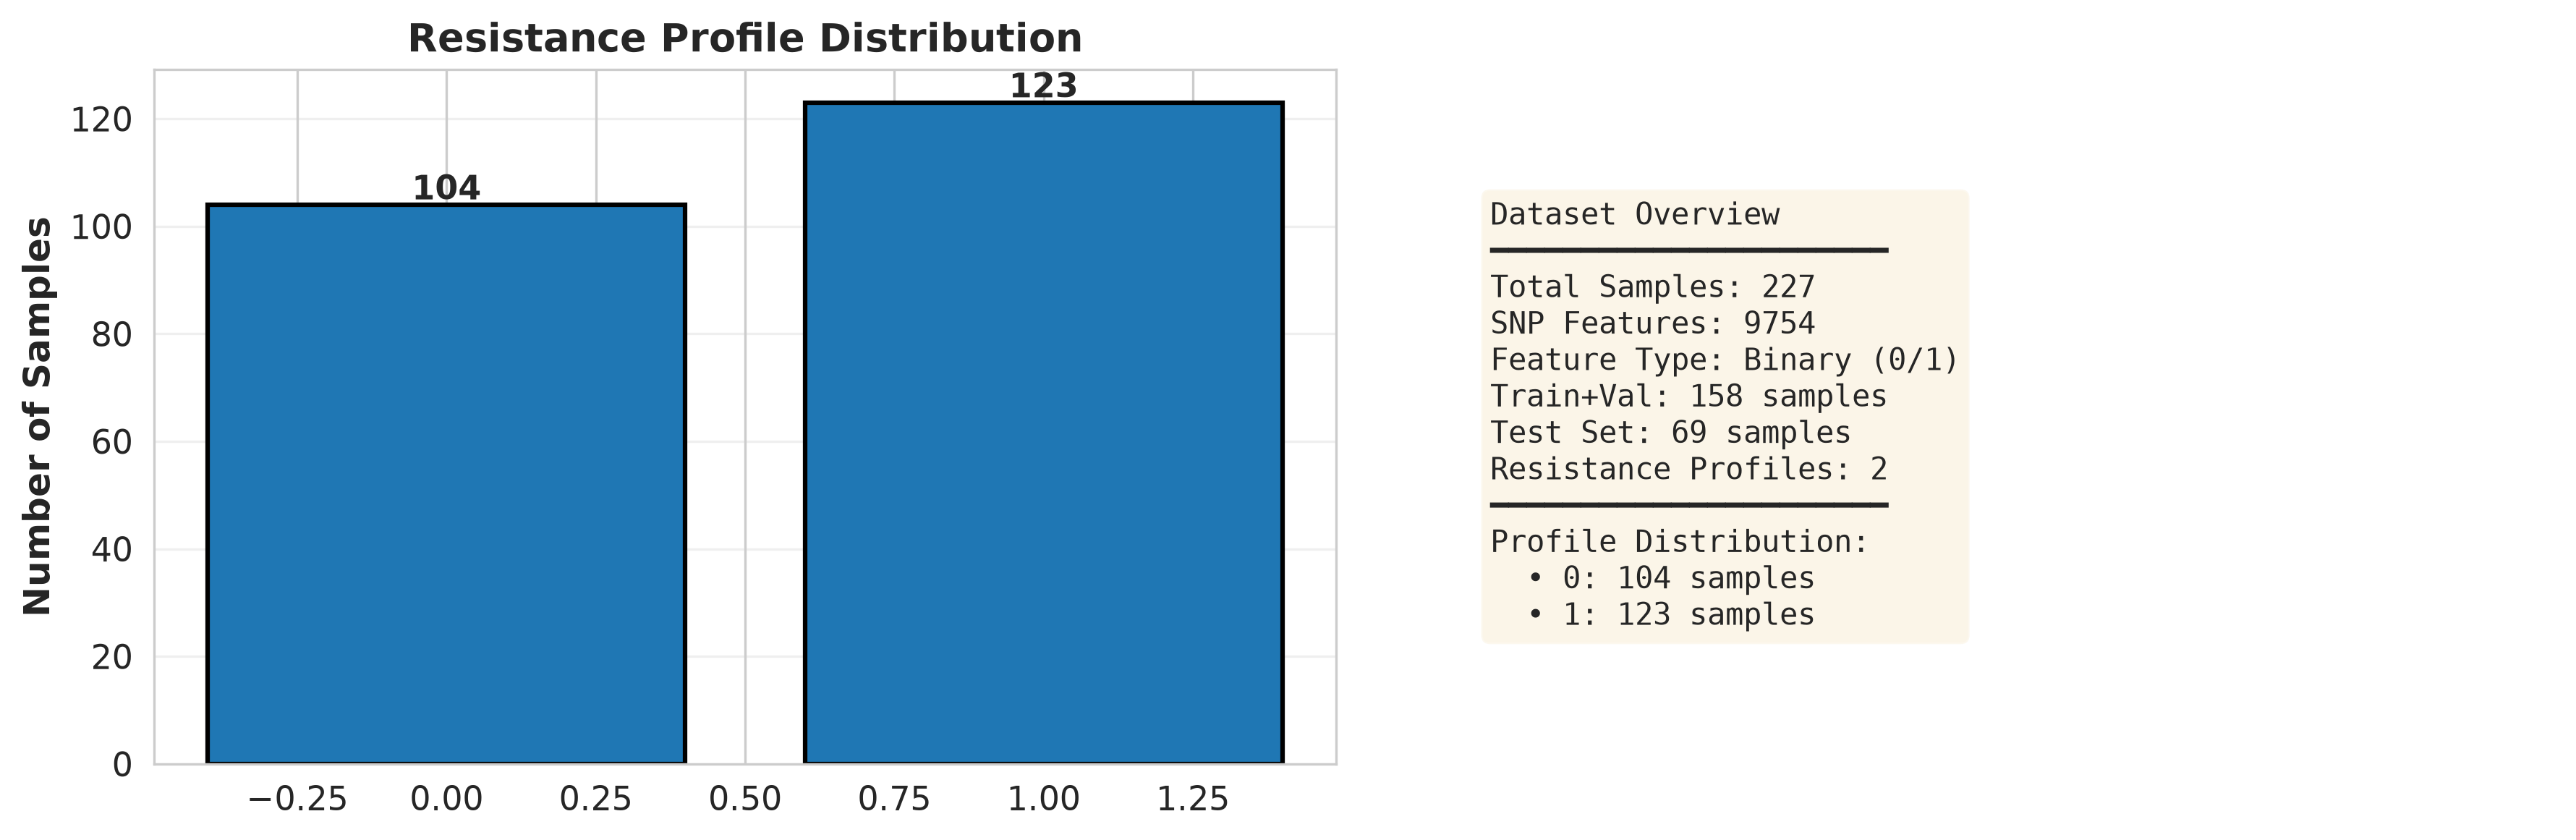

In [7]:
# Data composition
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Resistance profile distribution
unique, counts = np.unique(y, return_counts=True)
axes[0].bar(unique, counts, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Number of Samples', fontweight='bold')
axes[0].set_title('Resistance Profile Distribution', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(zip(unique, counts)):
    axes[0].text(i, count + 1, str(count), ha='center', fontweight='bold')

# Data statistics
axes[1].axis('off')
stats_text = f'''Dataset Overview\n━━━━━━━━━━━━━━━━━━━━━━\nTotal Samples: {X.shape[0]}\nSNP Features: {X.shape[1]}\nFeature Type: Binary (0/1)\nTrain+Val: {X_train_total.shape[0]} samples\nTest Set: {X_test.shape[0]} samples\nResistance Profiles: {len(unique)}\n━━━━━━━━━━━━━━━━━━━━━━\nProfile Distribution:\n{chr(10).join([f'  • {u}: {c} samples' for u, c in zip(unique, counts)])}'''
axes[1].text(0.1, 0.5, stats_text, fontfamily='monospace', fontsize=10, 
            verticalalignment='center', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('fig01_data_summary.png', dpi=300, bbox_inches='tight')
plt.show()


### 2.2 Principal Component Analysis

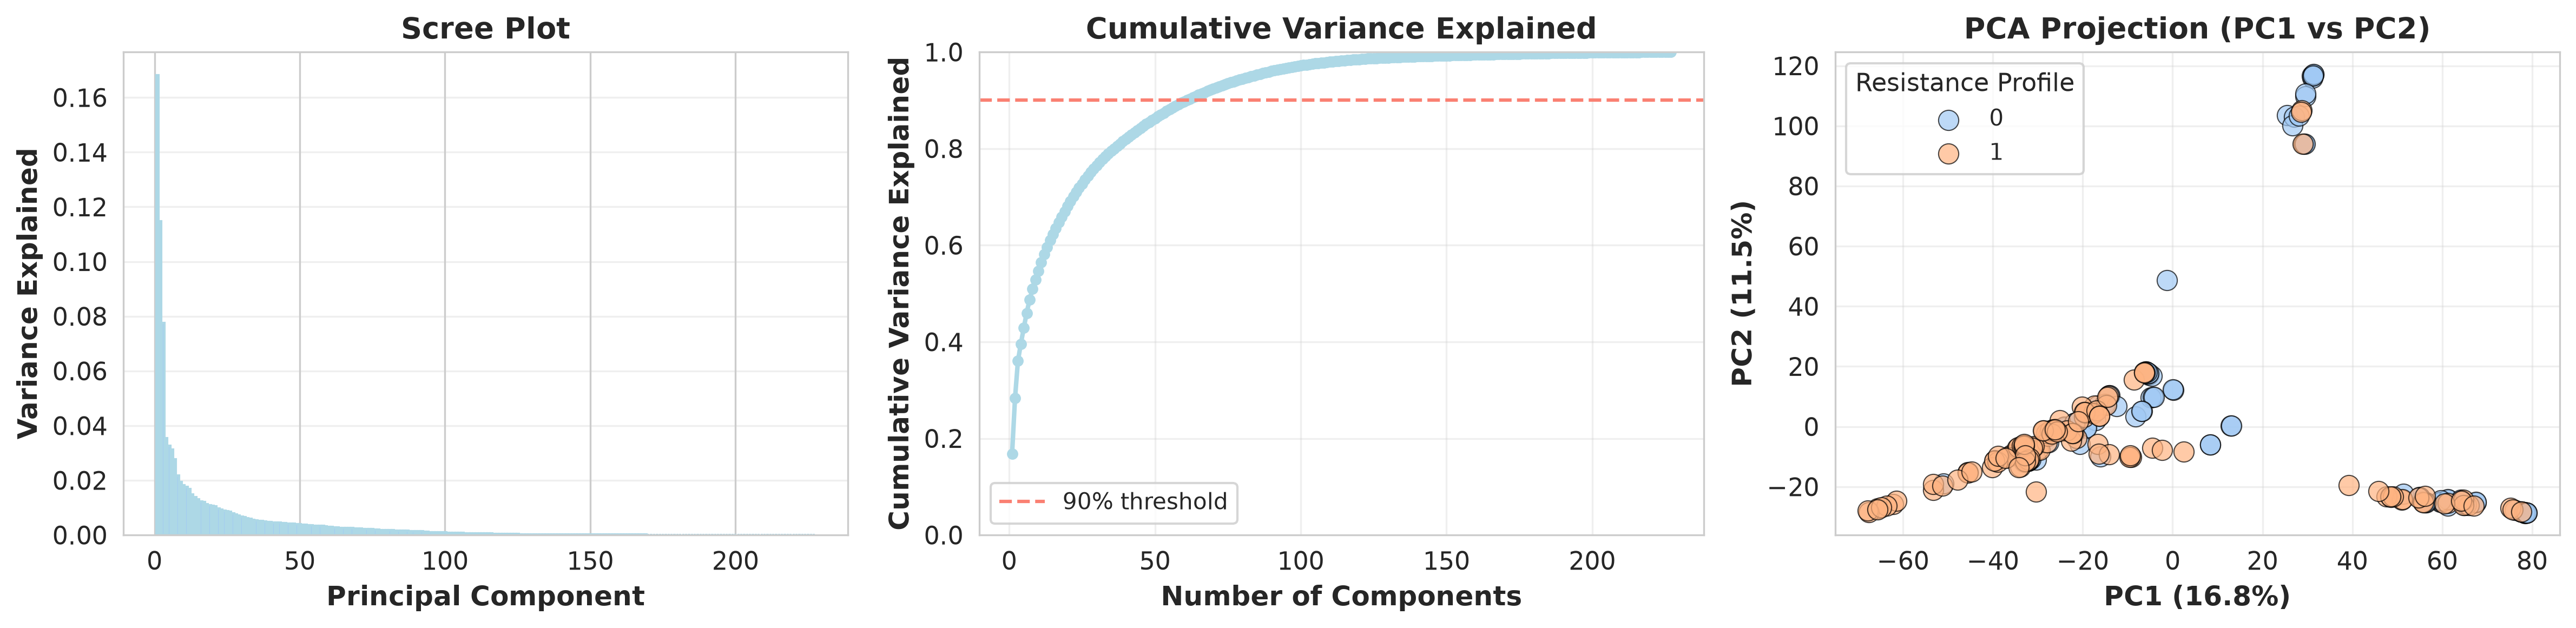

PCA: First 2 PCs explain 28.29% of variance


In [28]:
# Perform PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=None)
X_pca = pca.fit_transform(X_scaled)

# Proportion of variance explained
pve = pca.explained_variance_ratio_
pve_cumsum = np.cumsum(pve)

# Create PCA figures
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scree plot
components = np.arange(1, len(pve) + 1)
axes[0].bar(components, pve, edgecolor='lightblue', linewidth=1)
axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Variance Explained', fontweight='bold')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(components, pve_cumsum, 'o-', linewidth=2, markersize=4, color="lightblue")
axes[1].axhline(y=0.90, color="salmon", linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Variance Explained', fontweight='bold')
axes[1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.0])

# PCA biplot
for profile in np.unique(y):
    idx = np.where(y == profile)[0]
    axes[2].scatter(X_pca[idx, 0], X_pca[idx, 1], label=profile, alpha=0.7, s=80, edgecolors='k', linewidth=0.5)
axes[2].set_xlabel(f'PC1 ({pve[0]*100:.1f}%)', fontweight='bold')
axes[2].set_ylabel(f'PC2 ({pve[1]*100:.1f}%)', fontweight='bold')
axes[2].set_title('PCA Projection (PC1 vs PC2)', fontweight='bold')
axes[2].legend(loc='best', title='Resistance Profile')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig02_pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'PCA: First 2 PCs explain {pve_cumsum[1]*100:.2f}% of variance')


### 2.3 Correspondence Analysis

Dropping 2 zero-sum rows and 0 zero-sum columns


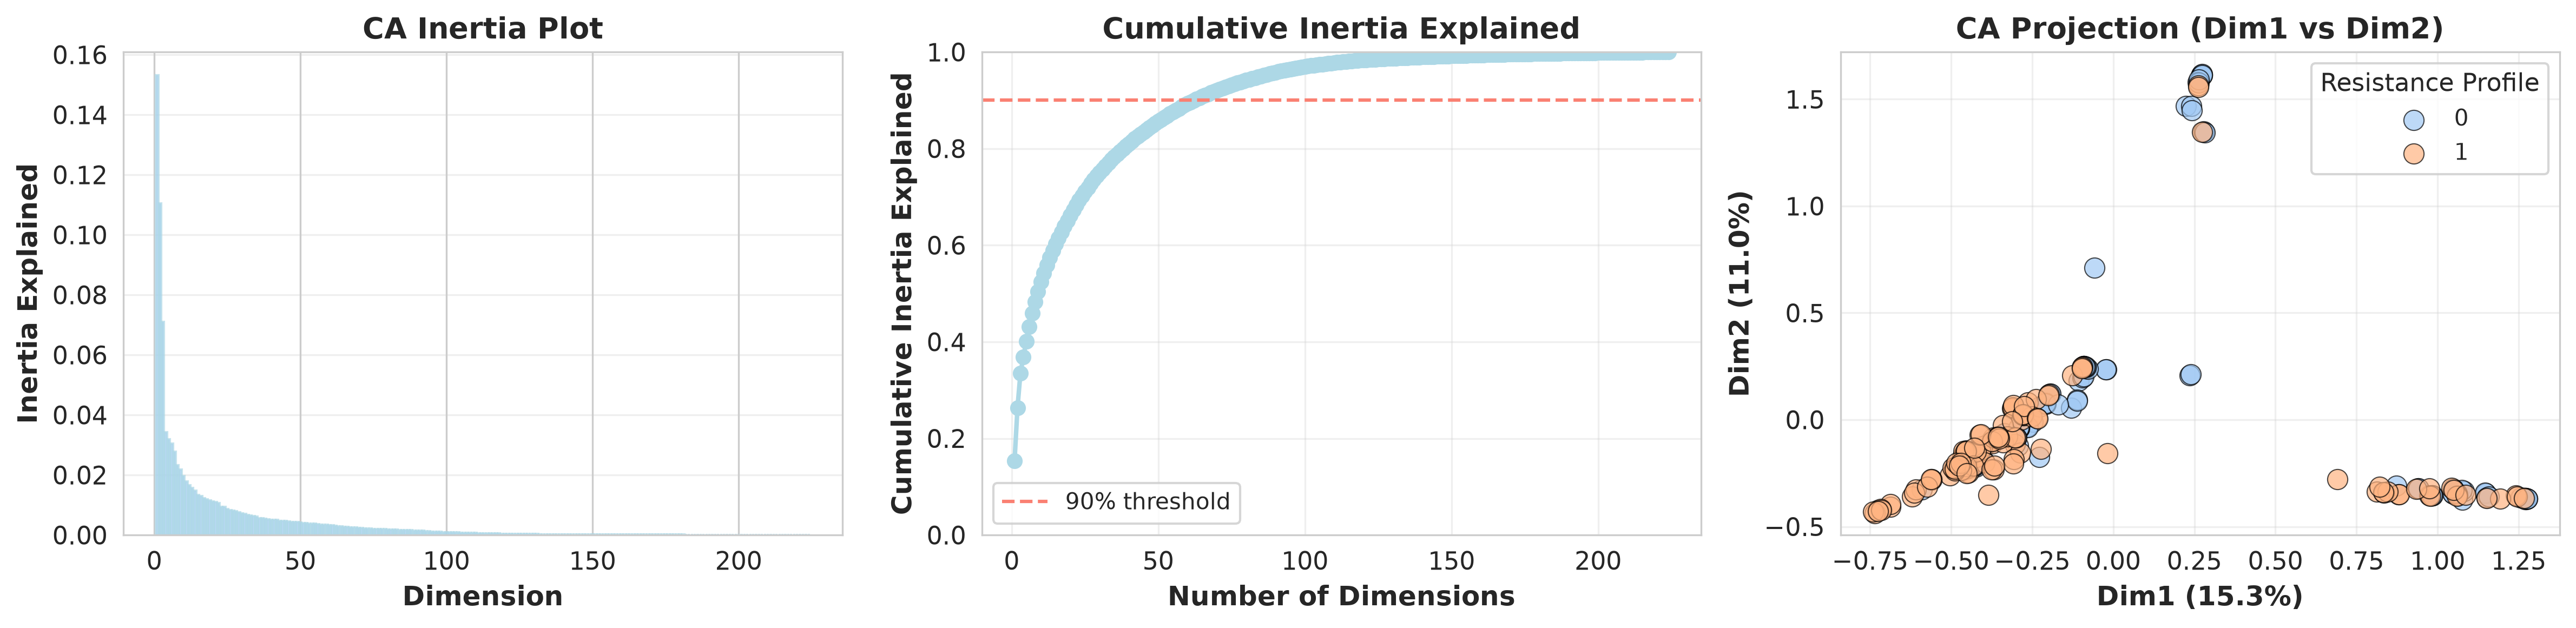

CA: First 2 dimensions explain 26.37% of inertia


In [40]:
# Perform Correspondence Analysis
snp_df = pd.DataFrame(X, columns=snp_data.columns)

# Guard against zero-sum rows/columns (causes NaN in CA's r**-0.5 / c**-0.5 step)
row_mask = snp_df.sum(axis=1) > 0
col_mask = snp_df.sum(axis=0) > 0
if not row_mask.all() or not col_mask.all():
    print(f"Dropping {(~row_mask).sum()} zero-sum rows and {(~col_mask).sum()} zero-sum columns")
snp_df_1 = snp_df.loc[row_mask, col_mask]
y_1 = y[row_mask.values]  # keep labels aligned with the filtered rows

n_comp = min(snp_df_1.shape) - 1  # max possible components for CA
ca = prince.CA(
    n_components=n_comp,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42
)
ca = ca.fit(snp_df_1)
X_ca = ca.row_coordinates(snp_df_1).values   # <-- changed from ca.transform(snp_df)
eigenvalues = ca.eigenvalues_
inertia = eigenvalues / eigenvalues.sum()
cumsum_inertia = np.cumsum(inertia)

# Create CA figures
n_show = len(inertia)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Inertia plot
components = np.arange(1, len(inertia) + 1)
axes[0].bar(components, inertia, alpha=0.7, edgecolor='lightblue', linewidth=1)
axes[0].set_xlabel('Dimension', fontweight='bold')
axes[0].set_ylabel('Inertia Explained', fontweight='bold')
axes[0].set_title('CA Inertia Plot', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative inertia
axes[1].plot(components, cumsum_inertia, 'o-', color='lightblue', linewidth=2, markersize=6)
axes[1].axhline(y=0.90, color='salmon', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Number of Dimensions', fontweight='bold')
axes[1].set_ylabel('Cumulative Inertia Explained', fontweight='bold')
axes[1].set_title('Cumulative Inertia Explained', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.0])

# CA biplot
for profile in np.unique(y):
    idx = np.where(y_1 == profile)[0]
    axes[2].scatter(X_ca[idx, 0], X_ca[idx, 1], label=profile, alpha=0.7, s=80, edgecolors='k', linewidth=0.5)
axes[2].set_xlabel(f'Dim1 ({inertia[0]*100:.1f}%)', fontweight='bold')
axes[2].set_ylabel(f'Dim2 ({inertia[1]*100:.1f}%)', fontweight='bold')
axes[2].set_title('CA Projection (Dim1 vs Dim2)', fontweight='bold')
axes[2].legend(loc='best', title='Resistance Profile')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig03_ca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'CA: First 2 dimensions explain {cumsum_inertia[1]*100:.2f}% of inertia')

## 3. Model Performance Comparison

### 3.1 Train All Models with Best Hyperparameters

In [41]:
# Dictionary to store models and results
models = {}
model_predictions = {}
model_probas = {}

# Logistic Regression
models['Logistic Regression'] = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)
models['Logistic Regression'].fit(X_train_total, y_train_total)

# KNN
knn_row = results_df[results_df['model'] == 'K-Nearest Neighbors']
knn_k = int(knn_row['hyperparameters'].values[0].split('k=')[1]) if not knn_row.empty else 5
models['KNN'] = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=knn_k)
)
models['KNN'].fit(X_train_total, y_train_total)

# SVM
svm_row = results_df[results_df['model'] == 'Support Vector Machine']
if not svm_row.empty:
    hyperparams = svm_row['hyperparameters'].values[0]
    svm_kernel = hyperparams.split('kernel=')[1].split(',')[0]
    svm_c = float(hyperparams.split('C=')[1])
else:
    svm_kernel, svm_c = 'linear', 1.0
models['SVM'] = make_pipeline(
    StandardScaler(),
    SVC(kernel=svm_kernel, C=svm_c, probability=True, random_state=42)
)
models['SVM'].fit(X_train_total, y_train_total)

# Decision Tree
dt_row = results_df[results_df['model'] == 'Decision Tree']
if not dt_row.empty:
    hyperparams = dt_row['hyperparameters'].values[0]
    dt_max_depth = hyperparams.split('max_depth=')[1].split(',')[0]
    dt_max_depth = None if dt_max_depth == 'None' else int(dt_max_depth)
    dt_min_samples = int(hyperparams.split('min_samples_split=')[1])
else:
    dt_max_depth, dt_min_samples = None, 2
models['Decision Tree'] = DecisionTreeClassifier(
    max_depth=dt_max_depth, min_samples_split=dt_min_samples, random_state=42
)
models['Decision Tree'].fit(X_train_total, y_train_total)

# XGBoost
xgb_row = results_df[results_df['model'] == 'XGBoost']
if not xgb_row.empty:
    hyperparams = xgb_row['hyperparameters'].values[0]
    xgb_max_depth = int(hyperparams.split('max_depth=')[1].split(',')[0])
    xgb_lr = float(hyperparams.split('learning_rate=')[1].split(',')[0])
    xgb_alpha = float(hyperparams.split('reg_alpha=')[1].split(',')[0])
    xgb_lambda = float(hyperparams.split('reg_lambda=')[1])
else:
    xgb_max_depth, xgb_lr, xgb_alpha, xgb_lambda = 5, 0.1, 0.0, 1.0
models['XGBoost'] = xgb.XGBClassifier(
    max_depth=xgb_max_depth, learning_rate=xgb_lr, reg_alpha=xgb_alpha, 
    reg_lambda=xgb_lambda, n_estimators=100, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0, use_label_encoder=False, eval_metric='logloss'
)
models['XGBoost'].fit(X_train_total, y_train_total)

# Get predictions and probabilities
for name, model in models.items():
    model_predictions[name] = model.predict(X_test)
    model_probas[name] = model.predict_proba(X_test)[:, 1]

print('All models trained successfully!')
print(f'Number of models: {len(models)}')

All models trained successfully!
Number of models: 5


### 3.2 Test Accuracy Comparison

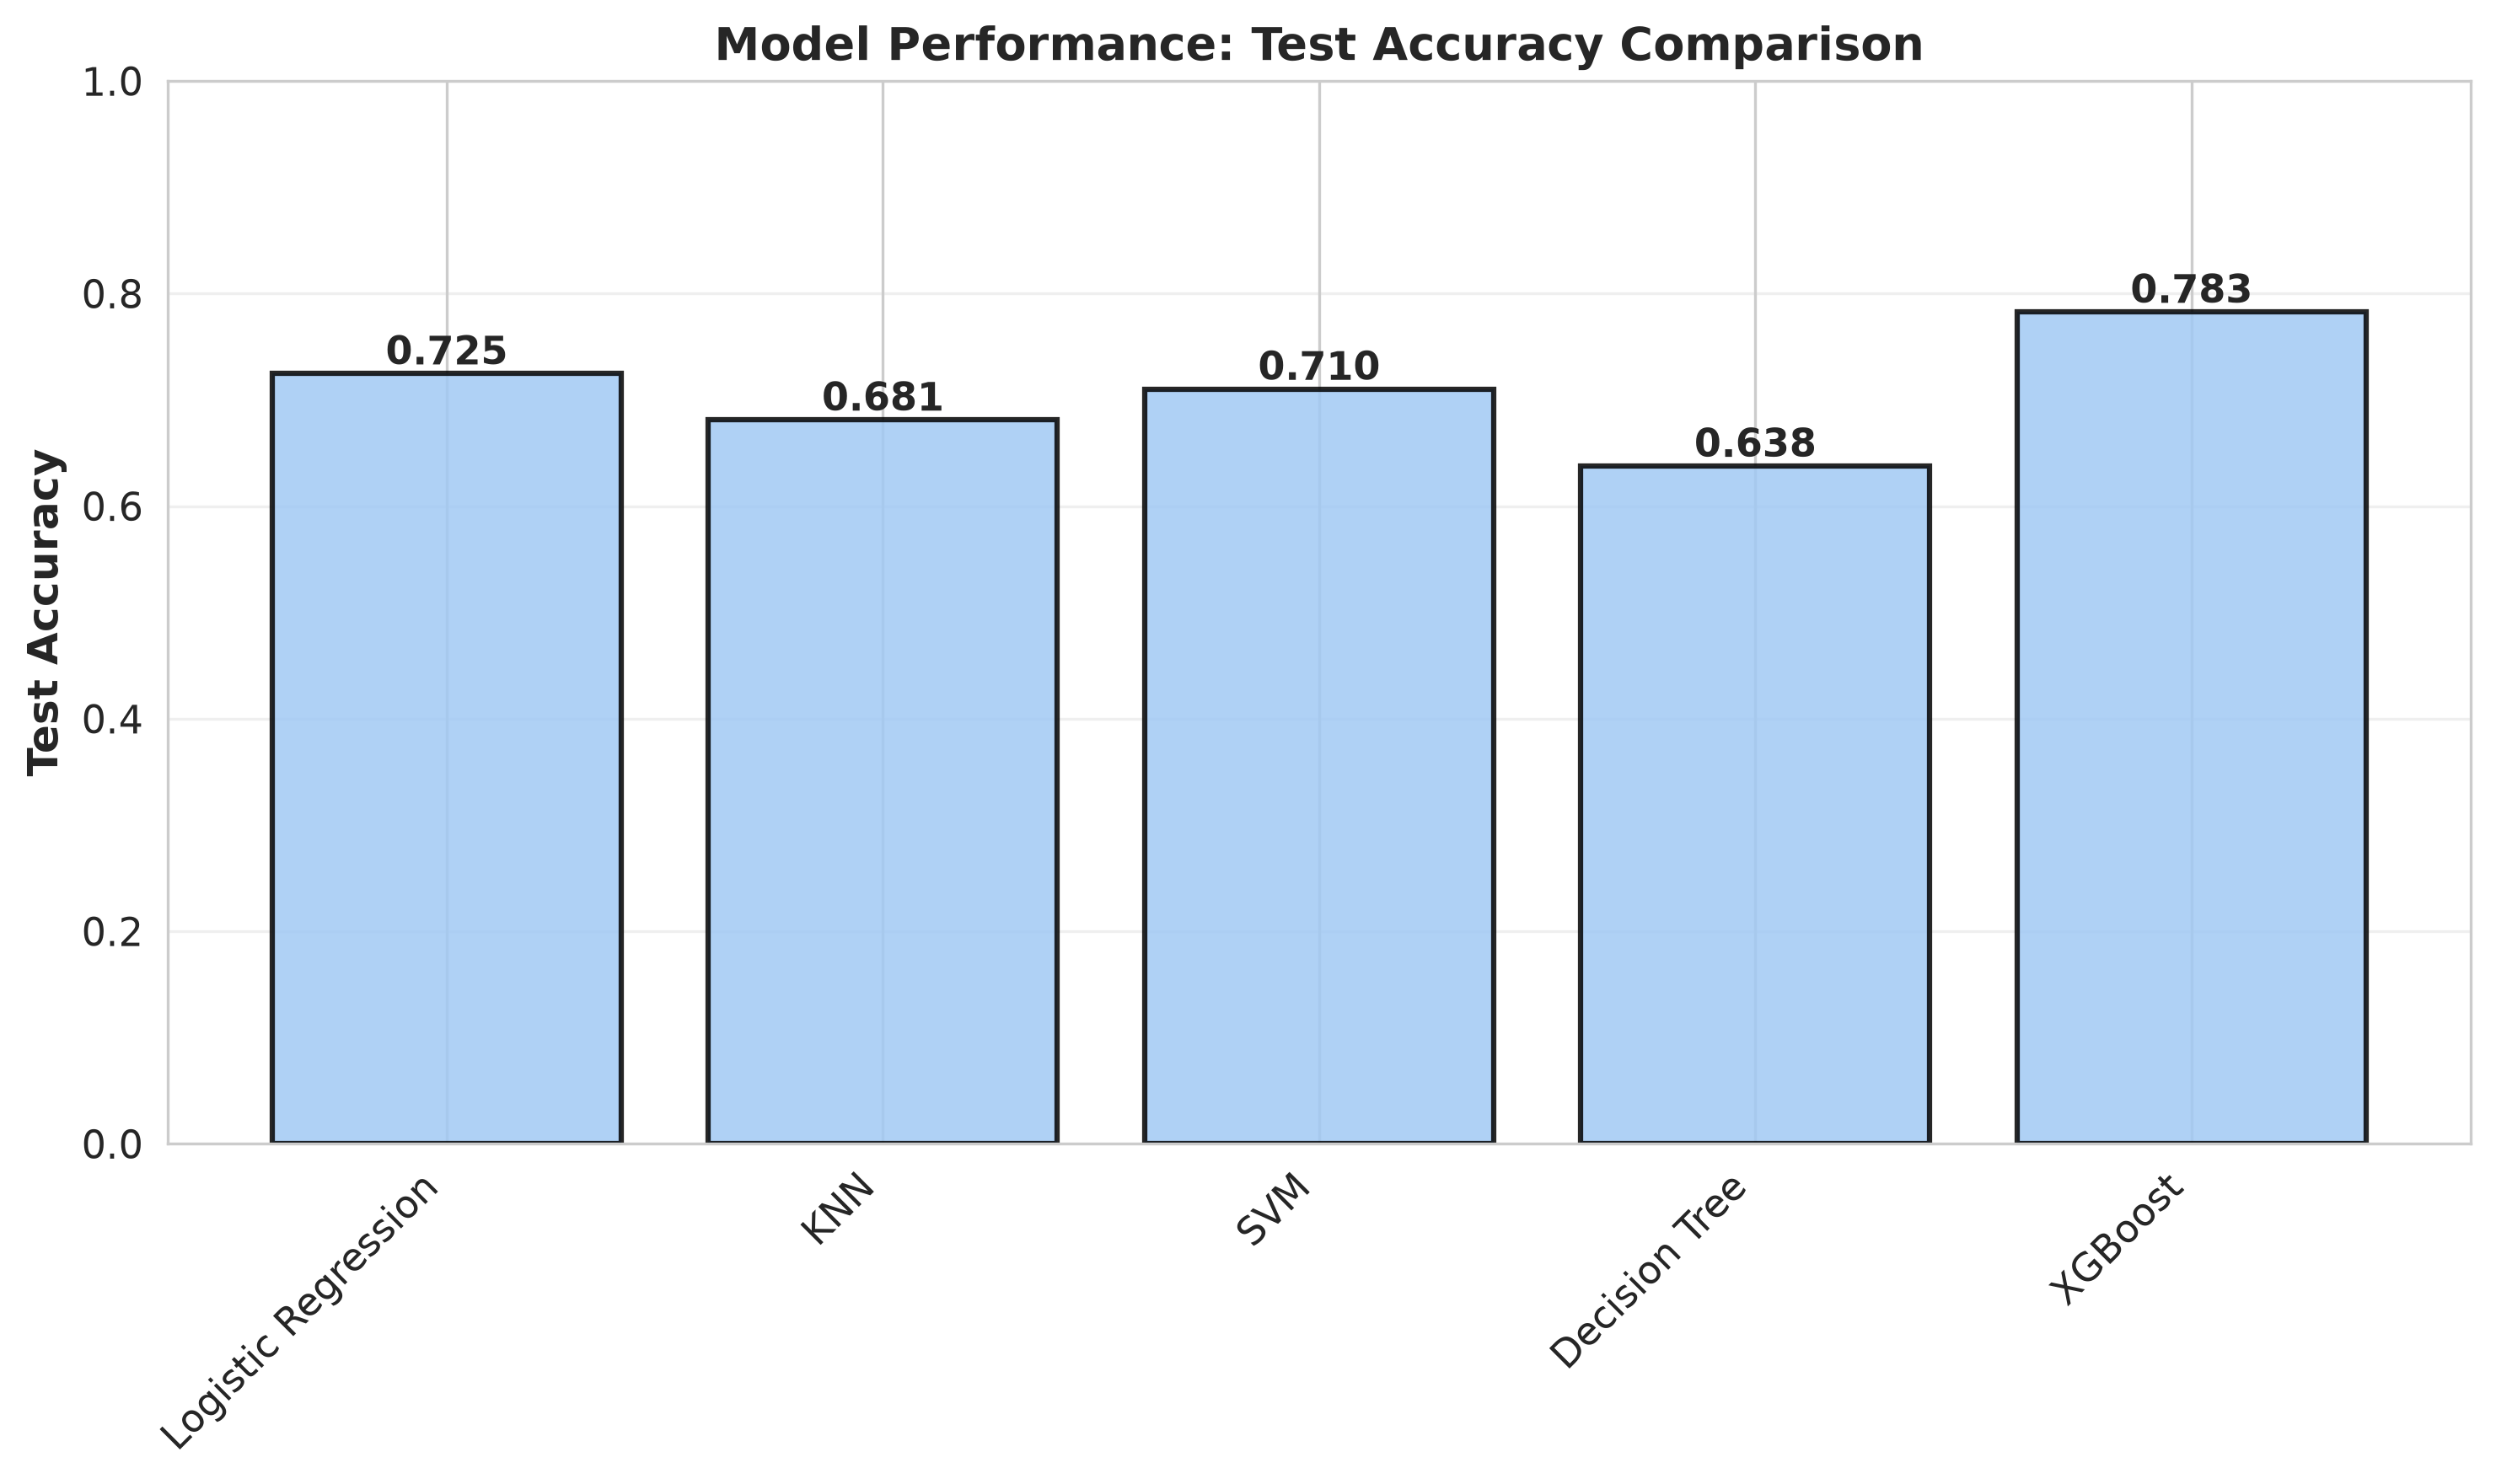


Test Accuracy Results:
  XGBoost             : 0.7826
  Logistic Regression : 0.7246
  SVM                 : 0.7101
  KNN                 : 0.6812
  Decision Tree       : 0.6377


In [44]:
# Calculate test accuracies
accuracies = {}
for name, model in models.items():
    accuracies[name] = model.score(X_test, y_test)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

bars = ax.bar(model_names, accuracy_values, edgecolor='black', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for bar, acc in zip(bars, accuracy_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Test Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Model Performance: Test Accuracy Comparison', fontweight='bold', fontsize=13)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig04_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print results
print('\nTest Accuracy Results:')
for name, acc in sorted(accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:20s}: {acc:.4f}')


### 3.3 ROC Curves Comparison

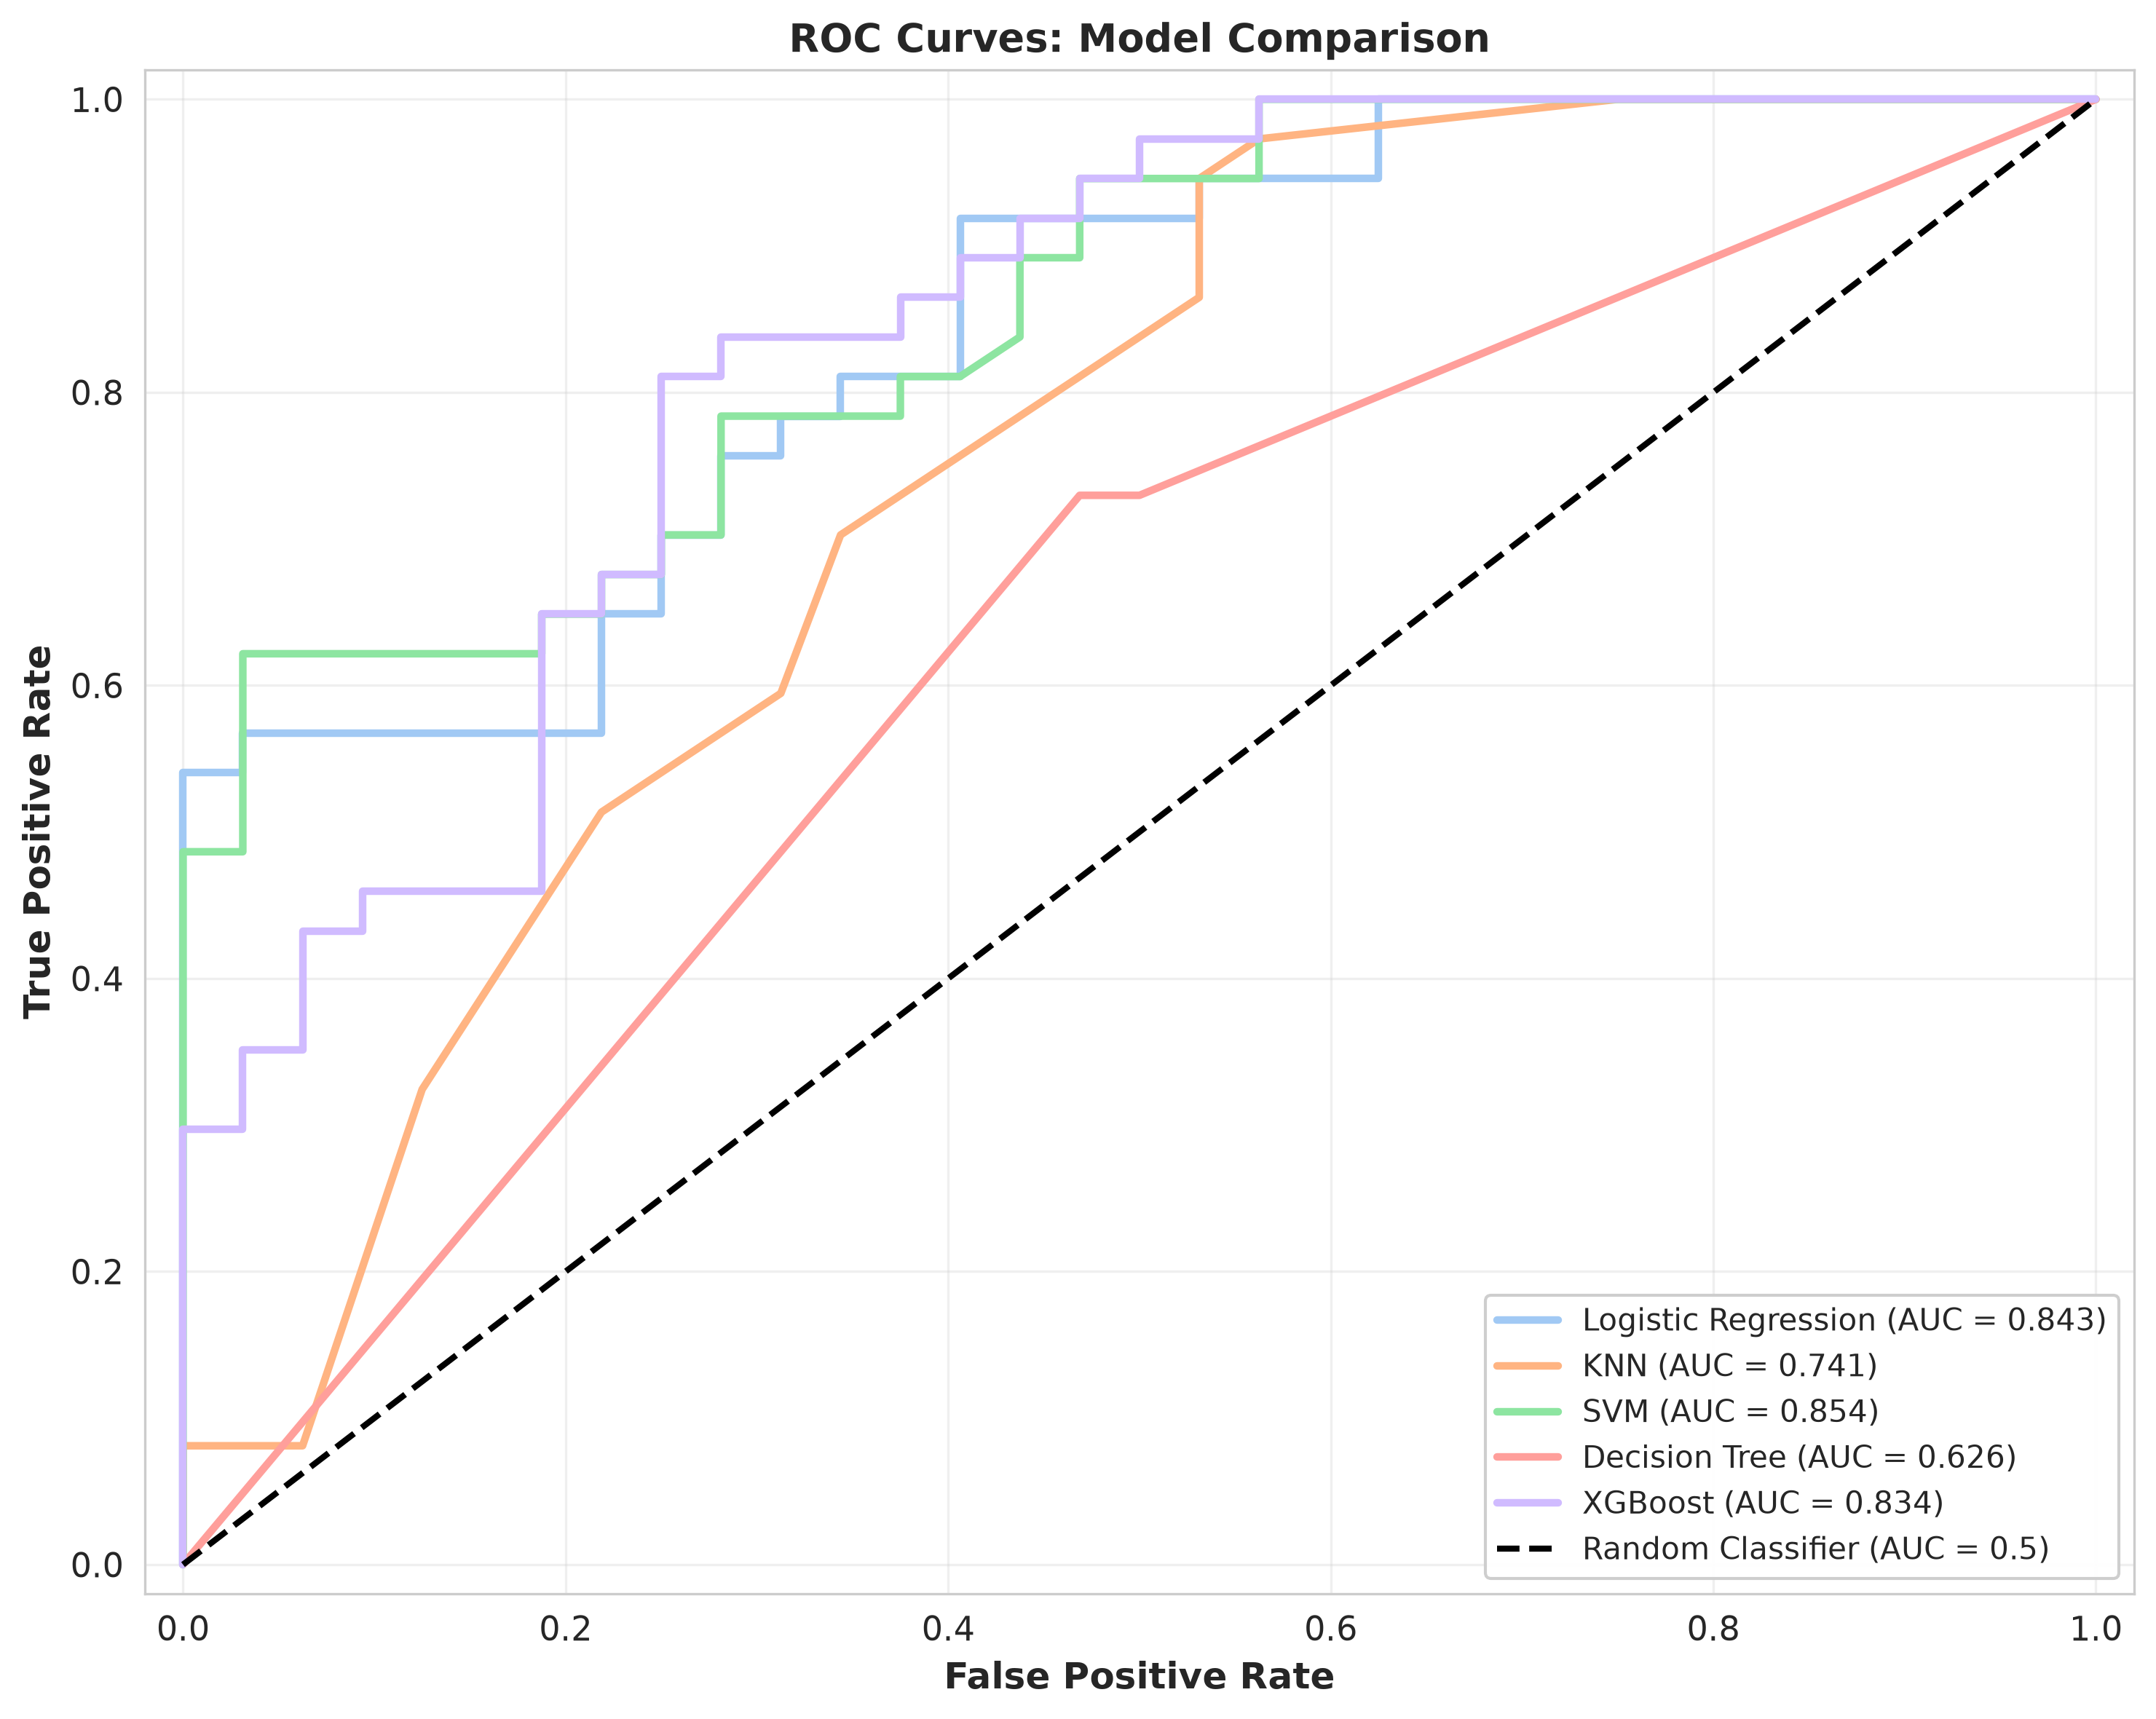


AUC Scores:
  Logistic Regression : 0.8429
  KNN                 : 0.7411
  SVM                 : 0.8543
  Decision Tree       : 0.6263
  XGBoost             : 0.8336


In [47]:
# Calculate ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

model_names = list(models.keys())

for (name, proba), color in zip(model_probas.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5)')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
ax.set_title('ROC Curves: Model Comparison', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig05_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC scores
print('\nAUC Scores:')
auc_scores = {}
for name, proba in model_probas.items():
    _, _, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    auc_scores[name] = auc_score
    print(f'  {name:20s}: {auc_score:.4f}')


### 3.4 Biomarker Consensus Analysis

In [49]:
# Calculate feature importance for each model
importances = {}

# Logistic Regression permutation importance
lr_pipe = models['Logistic Regression']
perm_imp_lr = permutation_importance(lr_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances['Logistic Regression'] = perm_imp_lr.importances_mean

#knn_pipe = models['KNN']
#perm_imp_knn = permutation_importance(knn_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
#importances['KNN'] = perm_imp_knn.importances_mean

# SVM permutation importance
svm_pipe = models['SVM']
perm_imp_svm = permutation_importance(svm_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances['SVM'] = perm_imp_svm.importances_mean

# XGBoost feature importance
# importances['Decision Tree'] = models['Decision Tree'].feature_importances_
importances['XGBoost'] = models['XGBoost'].feature_importances_

# Get top 200 biomarkers from each model
top_biomarkers = {}
for name, imp in importances.items():
    top_indices = np.argsort(imp)[-200:][::-1]
    top_biomarkers[name] = set(snp_names[top_indices])

print('Top 200 biomarkers identified for each model')

Top 200 biomarkers identified for each model


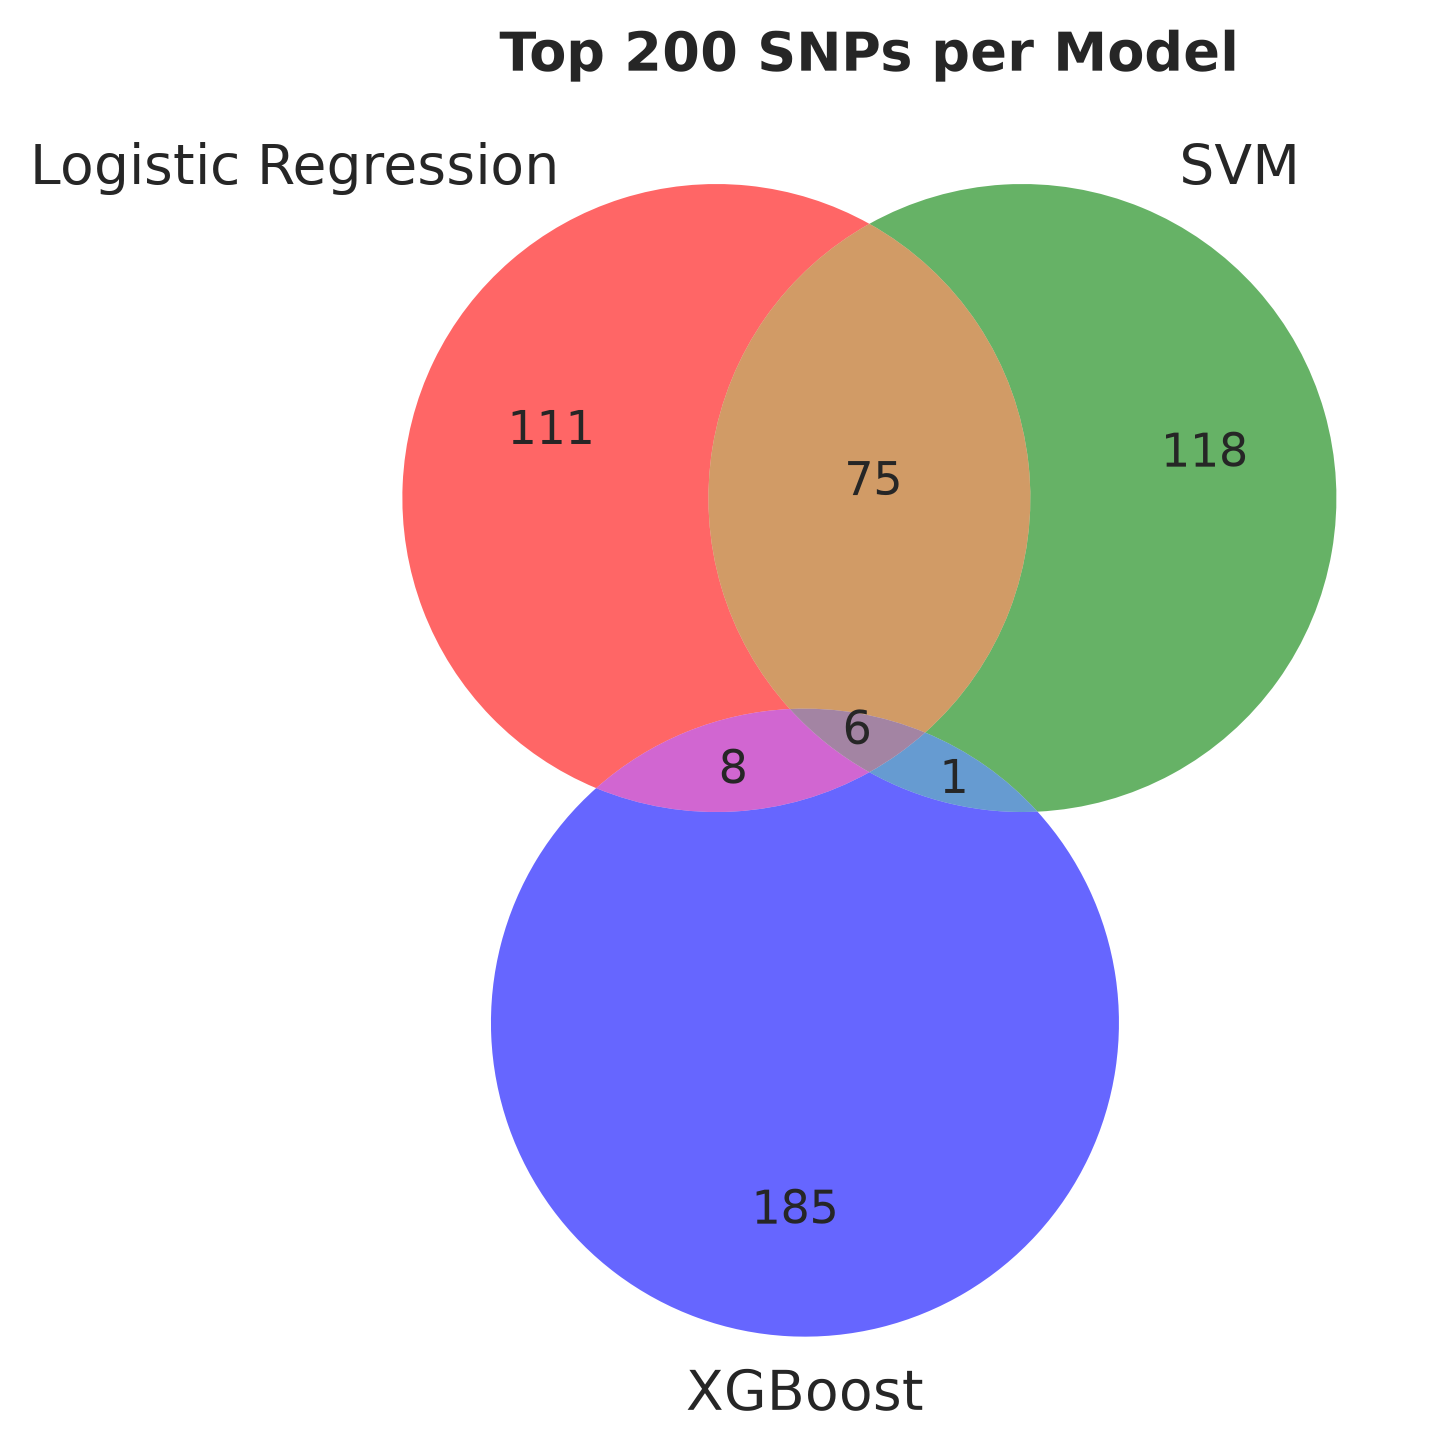

In [53]:
# Create Venn diagram for 3 models
fig, ax = plt.subplots(figsize=(5, 5))

model_list = list(top_biomarkers.keys())
sets = [top_biomarkers[m] for m in model_list]
sns.set_palette("pastel")
# Create 3-way Venn diagram
venn3(sets, set_labels=model_list, ax=ax, alpha=0.6)
ax.set_title('Top 200 SNPs per Model', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('fig06_biomarker_venn.png', dpi=300, bbox_inches='tight')
plt.show()

In [61]:
# All models agree
all_agree = set.intersection(*[top_biomarkers[m] for m in model_list])
print(f'\nSNPs in all 3 models: {len(all_agree)}')
if len(all_agree) > 0:
    print(f'{list(all_agree)[:5]}')

# Pairwise overlaps
print(f'\nPairwise Overlaps:')
for i, m1 in enumerate(model_list):
    for m2 in model_list[i+1:]:
        overlap = len(top_biomarkers[m1] & top_biomarkers[m2])
        jaccard = overlap / len(top_biomarkers[m1] | top_biomarkers[m2])
        print(f'  {m1:20s} ∩ {m2:20s}: {overlap:3d} biomarkers (Jaccard: {jaccard:.3f})')

# Consensus by agreement level
print(f'\nSNPs per model:')
all_snps = set.union(*[top_biomarkers[m] for m in model_list])
for level in range(3, 0, -1):
    consensus = [snp for snp in all_snps if sum([snp in top_biomarkers[m] for m in model_list]) == level]
    print(f'  {level} models agree: {len(consensus):3d} SNPs')


SNPs in all 3 models: 6
['snp__NZ_AP028077.1_1186954_G_A', 'snp__NZ_AP028077.1_2995623_GAGCGC_AAGCGC', 'snp__NZ_AP028077.1_690660_T_A', 'snp__NZ_AP028078.1_2483537_GCGA_G', 'snp__NZ_AP028077.1_1879502_T_G']

Pairwise Overlaps:
  Logistic Regression  ∩ SVM                 :  81 biomarkers (Jaccard: 0.254)
  Logistic Regression  ∩ XGBoost             :  14 biomarkers (Jaccard: 0.036)
  SVM                  ∩ XGBoost             :   7 biomarkers (Jaccard: 0.018)

SNPs per model:
  3 models agree:   6 SNPs
  2 models agree:  84 SNPs
  1 models agree: 414 SNPs
